<a href="https://colab.research.google.com/github/markmbarak8/The_Pytorch_Course/blob/main/module_01/module_01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pytorch end to end workfrow

In [479]:
what_we_re_going_to_cover={1:"data",
                           2:"build model",
                           3:"fitting the model to data (training)",
                           4:"making predictions and evaluating a model (inference)",
                           5:"saving and loading a model"}

In [480]:
what_we_re_going_to_cover

{1: 'data',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating a model (inference)',
 5: 'saving and loading a model'}

In [481]:
import torch as t
from torch import nn # nn contains all of Pytorch's building blocks for neural networks
import matplotlib.pyplot as plt

print(t.__version__)
# device agnostic code
device="cuda" if t.cuda.is_available() else "cpu"
device

2.11.0+cu128


'cuda'

### Data : Preparing and loading

In [482]:
# create known parameters
weight=0.7
bias=0.3

# create
start=0
end=1
step=0.02
X=t.arange(start,end,step).unsqueeze(dim=1)
y=weight*X+bias

In [483]:
X[:10]

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]])

In [484]:
y[:10]

tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])

In [485]:
len(X),len(y)

(50, 50)

### splitting data into train,validation and test sets

In [486]:
# Create a train/test split
train_split=int(0.8*len(X))
test_split=len(X)-train_split
train_split,test_split

(40, 10)

In [487]:
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]
len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

### Visualize

In [488]:
def plot_pred(train_data=X_train,train_lebels=y_train,test_data=X_test,test_labels=y_test,predictions=None):
    plt.figure(figsize=(10,7))
    plt.scatter(train_data,train_lebels,c="b",s=4,label="training data")
    plt.scatter(test_data,test_labels,c="g",s=4,label="test data")
    if(predictions!=None):
      plt.scatter(test_data,predictions,c="r",s=4,label="predictions")
    plt.legend(prop={"size":14})

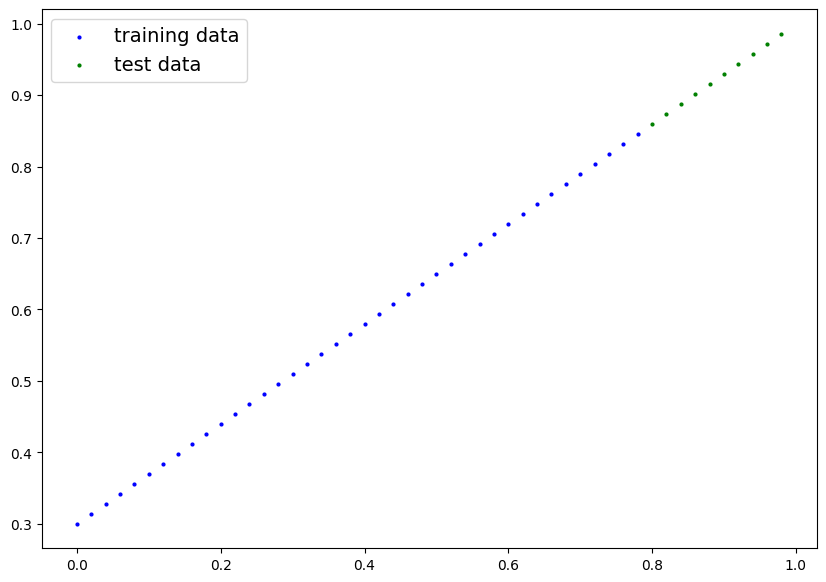

In [489]:
plot_pred(X_train,y_train)

### Build model

In [490]:
# Create a linear regression model class

class LinearRegressionModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights=nn.Parameter(t.randn(1,requires_grad=True,dtype=t.float))
    self.bias=nn.Parameter(t.randn(1,requires_grad=True,dtype=t.float))
  def forward(self,x:t.Tensor)->t.Tensor:
    return self.weights*x+self.bias

### Pytorch model building essentials

* torch.nn - contains all of the building for computational graphs (a neural network can be considered a computational graph)
* torch.nn.Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us
*torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward()
*torch.optim - this where the optimizers in Pytorch live, they will help with gradient descent.
* def forward() - All nn.Module subclasses require you to overwrite forward

### Checking the contents of our PyTorch model
Now we've created a model, let's see what's inside...
So we can check out our model parameters or what's inside our model using `.parameters()`

In [491]:
# create a manual seed
t.manual_seed(42)

In [492]:
# Create an instance of the model
t.manual_seed(42)
model_0=LinearRegressionModelV1()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [493]:
# list named parameters
m_dict=model_0.state_dict()
m_dict

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making predictions using `torch.inference_mode()`

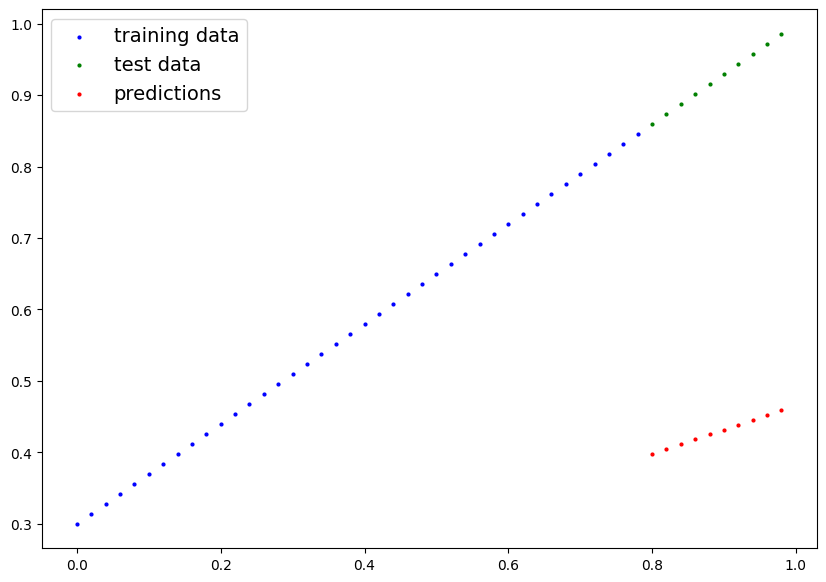

In [494]:
with t.inference_mode():
  y_preds=model_0(X_test)
plot_pred(predictions=y_preds)

### Training a model

* the whole idea of training is to move the model from random parameters to some known parameters

In [495]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [496]:
## loss functions for regression problems
nn.L1Loss ## mean absolute loss
nn.MSELoss ## mean squarred error

torch.nn.modules.loss.MSELoss

In [497]:
## setup a loss function
loss_fn=nn.L1Loss()

## setup an optimizer
optimizer=t.optim.SGD(params=model_0.parameters(),
                      lr=0.01) # lr : learning rate

## Building a training (and testing) loop in pytorch

A couple of things we need in a training loop:
0. loop through the data
1. Forward pass to make predictions on the data
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward
5. Optimizer step

In [498]:
list(model_0.eval().parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [499]:
list(model_0.train().parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [500]:
t.manual_seed(42)
# an epoch: one loop through the data
epochs=168

epoch_count=[]
loss_values=[]
test_loss_values=[]

# 0. loop through the data
for epoch in range(epochs):

  # set the model to train mode
  model_0.train()

  # forward pass
  y_pred=model_0(X_train)

  # calculate the loss
  loss=loss_fn(y_pred,y_train)
  print(epoch)
  print(f"Loss={loss}")

  # optimizer
  optimizer.zero_grad()

  # perform backpropagation
  loss.backward()

  # optimizer step (gradient descent)
  optimizer.step()

  # evaluate
  model_0.eval()
  with t.inference_mode():
    test_pred=model_0(X_test)
    test_loss=loss_fn(test_pred,y_test)
    print(f"Test loss: {test_loss}")
    print()
  epoch_count.append(epoch)
  loss_values.append(loss.detach())
  test_loss_values.append(test_loss)

0
Loss=0.31288138031959534
Test loss: 0.48106518387794495

1
Loss=0.3013603389263153
Test loss: 0.4675942063331604

2
Loss=0.28983935713768005
Test loss: 0.4541231691837311

3
Loss=0.2783183455467224
Test loss: 0.44065219163894653

4
Loss=0.26679736375808716
Test loss: 0.4271811842918396

5
Loss=0.2552763521671295
Test loss: 0.41371020674705505

6
Loss=0.24375534057617188
Test loss: 0.40023916959762573

7
Loss=0.23223432898521423
Test loss: 0.3867681920528412

8
Loss=0.22071333229541779
Test loss: 0.37329721450805664

9
Loss=0.20919232070446014
Test loss: 0.3598262071609497

10
Loss=0.1976713240146637
Test loss: 0.3463551998138428

11
Loss=0.18615034222602844
Test loss: 0.3328842222690582

12
Loss=0.1746293306350708
Test loss: 0.3194132149219513

13
Loss=0.16310831904411316
Test loss: 0.30594223737716675

14
Loss=0.1515873372554779
Test loss: 0.2924712300300598

15
Loss=0.14006635546684265
Test loss: 0.27900025248527527

16
Loss=0.1285453587770462
Test loss: 0.2655292749404907

17
Loss

In [501]:
  model_0.state_dict()

OrderedDict([('weights', tensor([0.6947])), ('bias', tensor([0.3028]))])

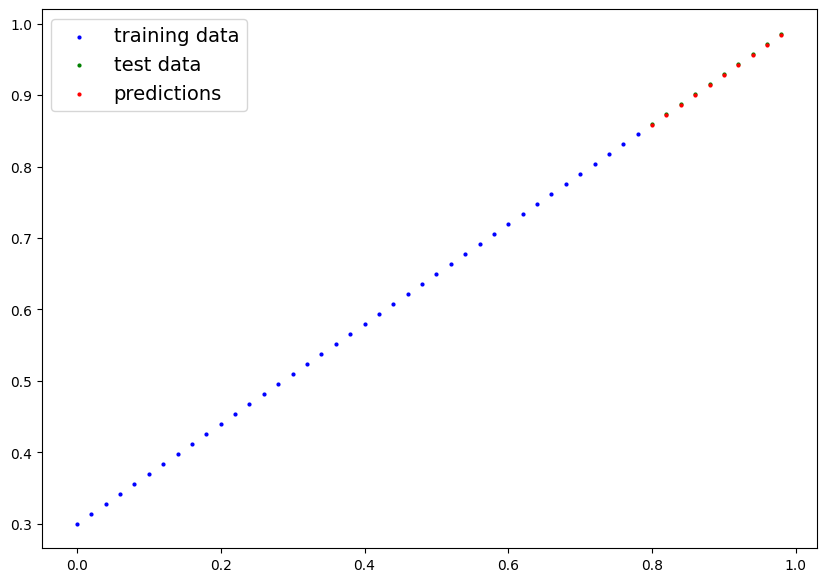

In [502]:
with t.inference_mode():
  y_preds=model_0(X_test)
plot_pred(predictions=y_preds)

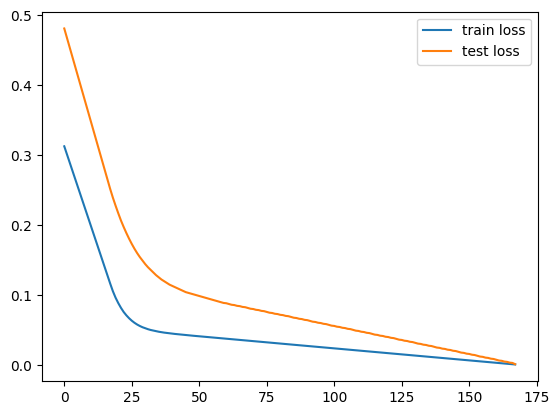

In [504]:
plt.plot(epoch_count,loss_values,label="train loss")
plt.plot(epoch_count,test_loss_values,label="test loss")
plt.legend()

## Saving a model/loading

In [507]:
## saving a model
from pathlib import Path

# create a model's directory
model_path=Path("models")
model_path.mkdir(parents=True,exist_ok=True)

# create model save path
MODEL_NAME="01_pytorch_workflow_model.pth"
model_save_path=model_path/MODEL_NAME

# save the model state dict
print(f"Saving model to: {model_save_path}")
t.save(obj=model_0.state_dict(),f=model_save_path)


Saving model to: models/01_pytorch_workflow_model.pth


In [509]:
loaded_model_0=LinearRegressionModelV1()
loaded_model_0.load_state_dict(t.load(f=model_save_path))

loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6947])), ('bias', tensor([0.3028]))])

In [510]:
dict_=t.load(f=model_save_path)
dict_

OrderedDict([('weights', tensor([0.6947])), ('bias', tensor([0.3028]))])